# Cargar dataset

In [ ]:
from google.colab import drive
import pandas as pd

# Cargar el dataset desde un Drive público
file_ID = '1YgzbRENfXqV-L-o7iuUoll7puwHkJAVs'
file_url = f'https://drive.google.com/uc?id={file_ID}'

spotify_data = pd.read_excel(file_url)

# Mostrar las primeras columnas del dataset
spotify_data.head()

HTTPError: HTTP Error 404: Not Found

# Limpieza de datos


## Verificación e imputación de datos

In [ ]:
spotify_data.head(), spotify_data.isnull().sum(), spotify_data.describe(include='all')

(                            track_name  artist_count  released_year  \
 0  Seven (feat. Latto) (Explicit Ver.)             2           2023   
 1                                 LALA             1           2023   
 2                              vampire             1           2023   
 3                         Cruel Summer             1           2019   
 4                       WHERE SHE GOES             1           2023   
 
    released_month  released_day  in_spotify_playlists  in_spotify_charts  \
 0               7            14                   553                147   
 1               3            23                  1474                 48   
 2               6            30                  1397                113   
 3               8            23                  7858                100   
 4               5            18                  3133                 50   
 
      streams  in_apple_playlists  in_apple_charts  ...  in_deezer_charts  key  \
 0  141381703       

## Eliminación de nulos

In [ ]:
# Imputar valores nulos en la columna 'key' con la moda
spotify_data['key'].fillna(spotify_data['key'].mode()[0], inplace=True)

# Verificar que no existan valores nulos
print("Valores nulos por columna:\n", spotify_data.isnull().sum())


Valores nulos por columna:
 track_name              0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
key                     0
mode                    0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
dtype: int64


<ipython-input-3-b5ad94c31a9d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spotify_data['key'].fillna(spotify_data['key'].mode()[0], inplace=True)


## Descargar dataset modificado

In [ ]:
# Guardar el archivo Excel modificado
modified_file_path = 'Spotify_Most_Streamed_Songs_V2.xlsx'
spotify_data.to_excel(modified_file_path, index=False)

# Descargar el archivo en Google Colab
from google.colab import files
files.download(modified_file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Matriz de correlación

In [ ]:
# Importa las bibliotecas necesarias
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Selecciona solo las columnas numéricas para el cálculo de la correlación
numeric_columns = spotify_data.select_dtypes(include=np.number).columns
correlation_matrix = spotify_data[numeric_columns].corr()

# Aplicar filtro para mostrar solo correlaciones mayores a 0.3 o menores a -0.3
filtered_corr_matrix = correlation_matrix.where((correlation_matrix > 0.3) | (correlation_matrix < -0.3))

# Mostrar la matriz de correlación filtrada
print("\nMatriz de correlación filtrada:")
print(filtered_corr_matrix)

# Graficar la matriz de correlación filtrada como un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, mask=filtered_corr_matrix.isnull())
plt.title("Matriz de Correlación de Canciones de Spotify (filtrada)")
plt.show()

# Analisis de modelos de regresión lineal multiple

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Convertir la columna 'streams' a numérica
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

# Variables independientes (X) y dependiente (y)
X = spotify_data[['streams']]
y = spotify_data[['in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists']]

# Eliminar filas con valores faltantes después de la conversión
X = X.dropna()
y = y.loc[X.index]  #

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal múltiple
multi_linear_model = LinearRegression()
multi_linear_model.fit(X_train, y_train)


# Realizar predicciones en el conjunto de prueba
y_pred = multi_linear_model.predict(X_test)

# Calcular métricas y graficar para cada variable dependiente
for i, column in enumerate(y.columns):
    mse = mean_squared_error(y_test[column], y_pred[:, i])
    r2 = r2_score(y_test[column], y_pred[:, i])
    print(f"{column} - MSE: {mse:.2f}, R²: {r2:.2f}")

    # Graficar valores reales y predicciones para cada variable dependiente
    plt.figure(figsize=(10, 6))
    # Valores predichos
    plt.scatter(X_test, y_test[column], color='red', alpha=0.5, label='Predicciones')
    # Valores reales
    plt.scatter(X_test, y_pred[:, i], color='blue', alpha=0.5, label='Valores reales')

    # Línea de regresión (usando los puntos ordenados para una línea continua)
    sorted_indices = np.argsort(X_test.values.flatten())  # Ordena para una línea continua
    plt.plot(X_test.values.flatten()[sorted_indices], y_pred[:, i][sorted_indices], color='green', linestyle='--', linewidth=2, label='Línea de Predicción')

    # Personalización del gráfico
    plt.xlabel("Streams")
    plt.ylabel(column)
    plt.title(f"Regresión Lineal Múltiple - {column}\nMSE: {mse:.2f}, R²: {r2:.2f}")
    plt.legend()
    plt.show()

## R2 de 3 variables distintas

In [ ]:
r2_scores = {column: r2_score(y_test[column], y_pred[:, i]) for i, column in enumerate(y.columns)}


plt.figure(figsize=(8, 5))
plt.bar(r2_scores.keys(), r2_scores.values(), color=['blue', 'green', 'red'])
plt.ylabel('R²')
plt.title('Rendimiento de la Regresión Lineal Múltiple para cada variable dependiente')
plt.show()

## OLS Lineal

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Incluyendo la variable objetivo
X = spotify_data[['streams']]
y = spotify_data['in_apple_playlists']  # Variable objetivo

# Eliminar datos nulos
X = X.dropna()
y = y[X.index]

# Dividiendo datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenando
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# Prediciendo
y_pred_ols = ols_model.predict(X_test)

# Evaluando
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

# Imprimiendo
print(f"MSE (OLS): {mse_ols:.2f}")
print(f"R² (OLS): {r2_ols:.2f}")

# Graficando
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_pred_ols, color='blue', alpha=0.5, label='Valores reales')
plt.scatter(X_test, y_test, color='red', alpha=0.5, marker='x', label='Predicciones')
sorted_indices = X_test.values.flatten().argsort()
plt.plot(X_test.values.flatten()[sorted_indices], y_pred_ols[sorted_indices], color='green', linestyle='--', linewidth=2, label='Línea de Predicción')

# Personalización del gráfico
plt.xlabel("Streams")
plt.ylabel("in_apple_playlists")
plt.title("Regresión Lineal OLS: Valores Reales vs Predicciones")
plt.legend()
plt.show()

## Modelo lasso L1

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Incluyendo la variable objetivo
X = spotify_data[['streams']]
y = spotify_data['in_apple_playlists']  # Variable objetivo

# Eliminando valores nulos
X = X.dropna()
y = y[X.index]

# Dividiendo los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenando el modelo Lasso (L1)
lasso_model = Lasso(alpha=0.1)  # alpha controla la regularización en Lasso
lasso_model.fit(X_train, y_train)

# Prediciendo
y_pred_lasso = lasso_model.predict(X_test)

# Evaluando
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Imprimiendo las métricas
print(f"MSE (Lasso): {mse_lasso:.2f}")
print(f"R² (Lasso): {r2_lasso:.2f}")

# Graficando
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_pred_lasso, color='blue', alpha=0.5, label='Valores reales')
plt.scatter(X_test, y_test, color='red', alpha=0.5, marker='x', label='Predicciones')
sorted_indices = X_test.values.flatten().argsort()
plt.plot(X_test.values.flatten()[sorted_indices], y_pred_lasso[sorted_indices], color='green', linestyle='--', linewidth=2, label='Línea de Predicción')

# Personalización del gráfico
plt.xlabel("Streams")
plt.ylabel("in_apple_playlists")
plt.title("Regresión Lasso (L1): Valores Reales vs Predicciones")
plt.legend()
plt.show()

## Modelo L2 Ridge

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Incluyendo la variable objetivo
X = spotify_data[['streams']]
y = spotify_data['in_apple_playlists']  # Variable objetivo

# Eliminando valores
X = X.dropna()
y = y[X.index]  # Asegúrarses que y tenga las mismas filas que X

# Dividiendo los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenando el modelo Ridge (L2)
ridge_model = Ridge(alpha=0.1)  # alpha controla la regularización en Ridge
ridge_model.fit(X_train, y_train)

# Prediciendo
y_pred_ridge = ridge_model.predict(X_test)

# Evaluando
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Imprimiendo las métricas
print(f"MSE (Ridge): {mse_ridge:.2f}")
print(f"R² (Ridge): {r2_ridge:.2f}")

# Graficando
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_pred_ridge, color='blue', alpha=0.5,  label='Valores reales')
plt.scatter(X_test, y_test, color='red', alpha=0.5, marker='x', label='Predicciones')


# Ordenar los datos de prueba para trazar la línea de predicción correctamente
sorted_indices = X_test.values.flatten().argsort()

# Graficar la línea de predicción de Ridge
plt.plot(X_test.values.flatten()[sorted_indices], y_pred_ridge[sorted_indices], color='green', linestyle='--', linewidth=2, label='Línea de Predicción')

# Personalización del gráfico
plt.xlabel("Streams")
plt.ylabel("in_apple_playlists")
plt.title("Regresión Ridge (L2): Valores Reales vs Predicciones")
plt.legend()
plt.show()

## Imprimir resultados

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de las métricas
modelos = ['OLS', 'Lasso', 'Ridge']
mse_values = [mse_ols, mse_lasso, mse_ridge]
r2_values = [r2_ols, r2_lasso, r2_ridge]

# Crear subgráficos
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de MSE
ax[0].bar(modelos, mse_values, color='lightblue')
ax[0].set_title("Comparación de MSE entre Modelos")
ax[0].set_xlabel("Modelo")
ax[0].set_ylabel("MSE")

# Gráfico de R²
ax[1].bar(modelos, r2_values, color='lightgreen')
ax[1].set_title("R^2")
ax[1].set_xlabel("Modelo")
ax[1].set_ylabel("R²")

# Imprimir los valores de R² sobre las barras del gráfico de R²
for i, v in enumerate(r2_values):
    ax[1].text(i, v + 0.02, f"{v:.15f}", ha='center', va='bottom', fontsize=12)

# Mostrar los gráficos
plt.tight_layout()
plt.show()

# Analisis modelos de Regresión Polinómica (OLS, L1, L2)

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Generar términos polinómicos de grado 2
poly = PolynomialFeatures(degree=2)  # Puedes cambiar el grado aquí
X_poly = poly.fit_transform(X)

# Normalizar las variables independientes (X)
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_poly_scaled, y, test_size=0.2, random_state=42)

# Entrenar el modelo de regresión lineal en los datos polinómicos
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}")
print(f"R cuadrado (R²): {r2}")

# Gráfico de Valores Reales vs. Predicciones
plt.figure(figsize=(10, 6))

# Graficar los valores reales del conjunto de entrenamiento (en azul)
plt.scatter(np.arange(len(y_train)), y_train, color='blue', alpha=0.5, label='Valores Reales (Entrenamiento)')

# Graficar las predicciones del modelo sobre el conjunto de prueba (en rojo)
plt.scatter(np.arange(len(y_pred)), y_pred, color='red', alpha=0.5, label='Predicciones (Prueba)')

# Línea de Igualdad (para referencia)
plt.plot([min(y_train.min(), y_pred.min()), max(y_train.max(), y_pred.max())],
         [min(y_train.min(), y_pred.min()), max(y_train.max(), y_pred.max())],
         color='black', label='Línea de Igualdad')

# Personalización del gráfico
plt.xlabel("Índice de Datos")
plt.ylabel("Valores")
plt.title("Comparación: Valores Reales vs. Predicciones")
plt.legend()
plt.show()

## Regresión poli OLS

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Transformando variable a su forma polinomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Separando data
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Predicción de data
ols_poly_model = LinearRegression()
ols_poly_model.fit(X_train_poly, y_train)
y_pred_ols_poly = ols_poly_model.predict(X_test_poly)

# Evaluar el modelo Polinómico OLS
mse_ols_poly = mean_squared_error(y_test, y_pred_ols_poly)
r2_ols_poly = r2_score(y_test, y_pred_ols_poly)

# Imprimir las métricas
print(f"MSE (Polinómica OLS): {mse_ols_poly:.2f}")
print(f"R² (Polinómica OLS): {r2_ols_poly:.2f}")

# Graficar los valores reales vs. predicciones por índice
plt.figure(figsize=(10, 6))

# Graficar los valores reales con índice en el eje X
plt.scatter(range(len(y_test)), y_test, color='blue', alpha=0.5, label='Valores Reales')

# Graficar las predicciones con índice en el eje X
plt.scatter(range(len(y_pred_ols_poly)), y_pred_ols_poly, color='red', alpha=0.5, label='Predicciones')

# Línea de Igualdad (para referencia)
plt.plot([0, len(y_test)-1],
         [min(y_test.min(), y_pred_ols_poly.min()), max(y_test.max(), y_pred_ols_poly.max())],
         color='black', label='Línea de Igualdad')

# Personalización del gráfico
plt.xlabel("Índice de Datos")
plt.ylabel("Valores de la variable dependiente")
plt.title("Comparación: Valores Reales vs. Predicciones (Regresión Polinómica OLS)")
plt.legend()
plt.show()

## Regresión Poli Lasso (L1)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Transformar las características con un polinomio de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Estandarizar las características para mejorar la convergencia del modelo
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

# Crear el modelo Lasso con parámetros ajustados y entrenar
lasso_poly_model = Lasso(alpha=0.1, max_iter=50000, tol=1e-6)
lasso_poly_model.fit(X_train_poly_scaled, y_train)

# Predict
y_pred_lasso_poly = lasso_poly_model.predict(X_test_poly_scaled)

# Evaluando
mse_lasso_poly = mean_squared_error(y_test, y_pred_lasso_poly)
r2_lasso_poly = r2_score(y_test, y_pred_lasso_poly)

# Imprimir las métricas
print(f"MSE (Lasso Polinómica): {mse_lasso_poly:.2f}")
print(f"R² (Lasso Polinómica): {r2_lasso_poly:.2f}")

# Graficar los valores reales vs. predicciones
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', alpha=0.5, label='Valores Reales')
plt.scatter(range(len(y_pred_lasso_poly)), y_pred_lasso_poly, color='red', alpha=0.5, label='Predicciones')
plt.plot([0, len(y_test)-1],
         [min(y_test.min(), y_pred_lasso_poly.min()), max(y_test.max(), y_pred_lasso_poly.max())],
         color='black', label='Línea de Igualdad')

# Personalización del gráfico
plt.xlabel("Índice de Datos")
plt.ylabel("Valores de la variable dependiente")
plt.title("Comparación: Valores Reales vs. Predicciones (Lasso Polinómica)")
plt.legend()
plt.show()

## Regresión Poli Ridge L2

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Transformar las características con un polinomio de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Estandarizar las características para mejorar la convergencia del modelo
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

# Crear el modelo Ridge (L2) con parámetros ajustados y entrenar
ridge_poly_model = Ridge(alpha=1.0)
ridge_poly_model.fit(X_train_poly_scaled, y_train)

# Prediccionando
y_pred_ridge_poly = ridge_poly_model.predict(X_test_poly_scaled)

# Evaluando
mse_ridge_poly = mean_squared_error(y_test, y_pred_ridge_poly)
r2_ridge_poly = r2_score(y_test, y_pred_ridge_poly)

# Imprimir las métricas
print(f"MSE (Ridge Polinómica): {mse_ridge_poly:.2f}")
print(f"R² (Ridge Polinómica): {r2_ridge_poly:.2f}")

# Graficar los valores reales vs. predicciones
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', alpha=0.5, label='Valores Reales')
plt.scatter(range(len(y_pred_ridge_poly)), y_pred_ridge_poly, color='red', alpha=0.5, label='Predicciones')

# Línea de Igualdad (para referencia)
plt.plot([0, len(y_test)-1],
         [min(y_test.min(), y_pred_ridge_poly.min()), max(y_test.max(), y_pred_ridge_poly.max())],
         color='black', label='Línea de Igualdad')

# Personalización del gráfico
plt.xlabel("Índice de Datos")
plt.ylabel("Valores de la variable dependiente")
plt.title("Comparación: Valores Reales vs. Predicciones (Ridge Polinómica L2)")
plt.legend()
plt.show()

## Imprimir resultados

In [ ]:
import matplotlib.pyplot as plt

# Definir las métricas de cada modelo
models = ['Polinómico OLS', 'Polinómico Lasso', 'Polinómico Ridge']
mse_values = [mse_ols_poly, mse_lasso_poly, mse_ridge_poly]
r2_values = [r2_ols_poly, r2_lasso_poly, r2_ridge_poly]

# Crear el gráfico
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras para MSE
ax[0].bar(models, mse_values, color=['blue', 'green', 'orange'])
ax[0].set_title('MSE de los Modelos Polinómicos')
ax[0].set_ylabel('MSE')
ax[0].set_xlabel('Modelos')

# Gráfico de barras para R²
ax[1].bar(models, r2_values, color=['blue', 'green', 'orange'])
ax[1].set_title('R² de los Modelos Polinómicos')
ax[1].set_ylabel('R²')
ax[1].set_xlabel('Modelos')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Analisis Modelos Árbol de Decisión, Random Forest, y Support Vector Regression (SVR)

## Modelo Árbol de decisión

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
# Preprocesar la columna 'streams' para convertirla en numérica y eliminar filas con valores nulos
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')
spotify_data.dropna(subset=['streams', 'artist_count', 'in_spotify_playlists', 'released_year',
                            'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
                            'instrumentalness_%', 'liveness_%', 'speechiness_%'], inplace=True)

# Variables independientes (X) y dependiente (y)
X = spotify_data[['artist_count', 'released_year', 'danceability_%', 'valence_%', 'energy_%',
                  'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']]
y = spotify_data['in_spotify_playlists']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de Árbol de Decisión
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
# Evaluar el modelo Árbol de Decisión
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

## Modelo Random Forest

In [ ]:
# Modelo de Random Forest
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

## Modelo SVR

In [ ]:
# Modelo Support Vector Regression (SVR)
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)  # Usamos las características escaladas
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluar el modelo SVR
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

## Obtener resultados

In [ ]:
# Imprimir las métricas de cada modelo
print("Árbol de Decisión - MSE:", mse_tree, "R²:", r2_tree)
print("Random Forest - MSE:", mse_rf, "R²:", r2_rf)
print("Support Vector Regression - MSE:", mse_svr, "R²:", r2_svr)

#  Implementación y Comparación de Modelos de Clasificación Streams Danceability

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cargar el dataset desde la ruta especificada
file_path = '/content/Spotify_Most_Streamed_Songs_V2.xlsx'
spotify_data = pd.read_excel(file_path)
# Preprocesar la columna 'streams' para convertirla en numérica y eliminar filas con valores nulos
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')
spotify_data.dropna(subset=['streams', 'artist_count', 'in_spotify_playlists', 'released_year',
                            'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
                            'instrumentalness_%', 'liveness_%', 'speechiness_%'], inplace=True)

# Variables independientes (X) y dependiente (y)
X = spotify_data[['streams', 'danceability_%', 'energy_%', 'valence_%']]
y = spotify_data['in_spotify_playlists']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Modelo K-Nearest Neighbors (KNN)

In [ ]:
# Escalar las características para KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)  # Usando k=5 como valor inicial
knn_model.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluación del modelo
accuracy_knn = accuracy_score(y_test, y_pred_knn)
classification_rep = classification_report(y_test, y_pred_knn)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
# Imprimir las métricas de evaluación
print("Precisión del modelo KNN:", accuracy_knn)
print("Reporte de Clasificación:\n", classification_rep)
print("Matriz de Confusión:\n", conf_matrix)

## Gráfica

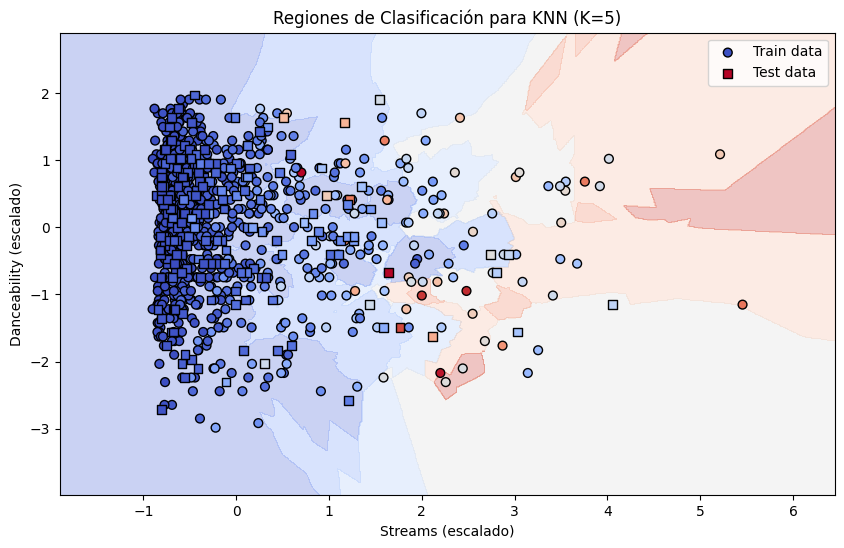

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Seleccionar solo dos características para visualizar el espacio de clasificación
X = spotify_data[['streams', 'danceability_%']]
y = spotify_data['in_spotify_playlists']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar el modelo KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Crear una malla de puntos para graficar las regiones de decisión
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predecir sobre la malla de puntos
Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualizar las regiones de decisión
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolor='k', cmap='coolwarm', marker='o', s=40, label="Train data")
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, edgecolor='k', cmap='coolwarm', marker='s', s=40, label="Test data")

# Etiquetas y leyenda
plt.xlabel("Streams (escalado)")
plt.ylabel("Danceability (escalado)")
plt.title("Regiones de Clasificación para KNN (K=5)")
plt.legend()
plt.show()


## Modelo Regresión Logística

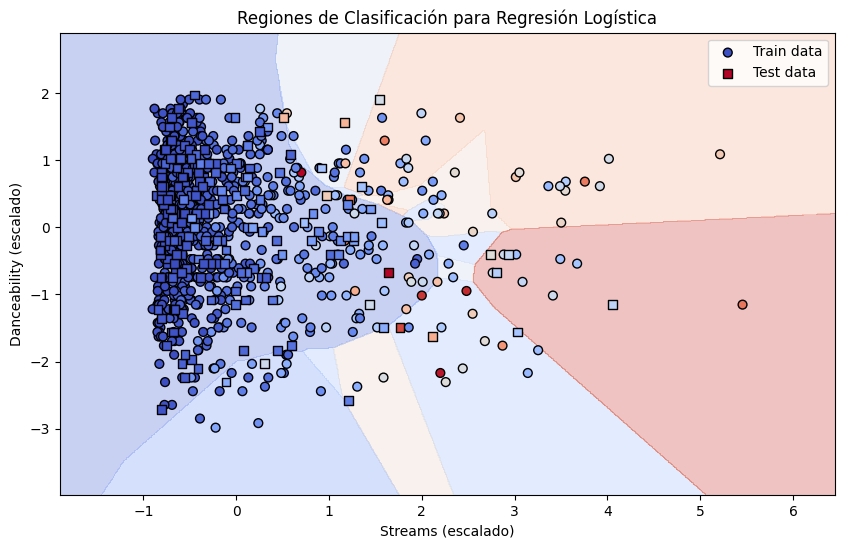

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Seleccionar dos características para el análisis
X = spotify_data[['streams', 'danceability_%']]
y = spotify_data['in_spotify_playlists']

# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características para la Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar el modelo de Regresión Logística
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Crear una malla de puntos para graficar las regiones de decisión
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predecir sobre la malla de puntos
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualizar las regiones de decisión
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')  # Regiones de decisión en azul y rojo
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolor='k', cmap='coolwarm', marker='o', s=40, label="Train data")
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, edgecolor='k', cmap='coolwarm', marker='s', s=40, label="Test data")

# Etiquetas y leyenda
plt.xlabel("Streams (escalado)")
plt.ylabel("Danceability (escalado)")
plt.title("Regiones de Clasificación para Regresión Logística")
plt.legend()
plt.show()


## Modelo Random Forest

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report



# Seleccionar las variables predictoras y la variable objetivo
X = spotify_data[['danceability_%', 'streams']]
y = spotify_data['in_spotify_playlists']

# Convertir las columnas a numéricas, manejando errores
# Si hay valores no numéricos, se reemplazarán con NaN
X['danceability_%'] = pd.to_numeric(X['danceability_%'], errors='coerce')
X['streams'] = pd.to_numeric(X['streams'], errors='coerce')

# Eliminar filas con valores NaN
X = X.dropna()
y = y[X.index]  # Asegurar que y tenga los mismos índices que X

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar las variables predictoras
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crear y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Realizar predicciones y evaluar el modelo
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Imprimir resultados
print(f"Precisión del modelo Random Forest: {accuracy * 100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

<ipython-input-25-c312129cc32f>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['danceability_%'] = pd.to_numeric(X['danceability_%'], errors='coerce')
<ipython-input-25-c312129cc32f>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['streams'] = pd.to_numeric(X['streams'], errors='coerce')


Precisión del modelo Random Forest: 0.00%

Reporte de clasificación:
               precision    recall  f1-score   support

          34       0.00      0.00      0.00       1.0
          58       0.00      0.00      0.00       0.0
          67       0.00      0.00      0.00       0.0
          86       0.00      0.00      0.00       1.0
         134       0.00      0.00      0.00       1.0
         148       0.00      0.00      0.00       0.0
         158       0.00      0.00      0.00       0.0
         161       0.00      0.00      0.00       1.0
         166       0.00      0.00      0.00       0.0
         168       0.00      0.00      0.00       0.0
         178       0.00      0.00      0.00       1.0
         181       0.00      0.00      0.00       1.0
         182       0.00      0.00      0.00       1.0
         200       0.00      0.00      0.00       1.0
         201       0.00      0.00      0.00       1.0
         209       0.00      0.00      0.00       1.0
         22

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

## Modelo Support Vector Machine (SVM)

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report



# Seleccionar las variables predictoras y la variable objetivo
X = spotify_data[['danceability_%', 'streams']]
y = spotify_data['in_spotify_playlists']

# Convertir las columnas a numéricas, manejando errores
# Si hay valores no numéricos, se reemplazarán con NaN
X['danceability_%'] = pd.to_numeric(X['danceability_%'], errors='coerce')
X['streams'] = pd.to_numeric(X['streams'], errors='coerce')

# Eliminar filas con valores NaN
X = X.dropna()
y = y[X.index]  # Asegurar que y tenga los mismos índices que X

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar las variables predictoras
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crear y entrenar el modelo SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Realizar predicciones y evaluar el modelo
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Imprimir resultados
print(f"Precisión del modelo SVM: {accuracy * 100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

<ipython-input-26-dc27165e68d2>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['danceability_%'] = pd.to_numeric(X['danceability_%'], errors='coerce')
<ipython-input-26-dc27165e68d2>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['streams'] = pd.to_numeric(X['streams'], errors='coerce')


Precisión del modelo SVM: 0.00%

Reporte de clasificación:
               precision    recall  f1-score   support

          34       0.00      0.00      0.00       1.0
          86       0.00      0.00      0.00       1.0
         134       0.00      0.00      0.00       1.0
         161       0.00      0.00      0.00       1.0
         178       0.00      0.00      0.00       1.0
         181       0.00      0.00      0.00       1.0
         182       0.00      0.00      0.00       1.0
         200       0.00      0.00      0.00       1.0
         201       0.00      0.00      0.00       1.0
         209       0.00      0.00      0.00       1.0
         226       0.00      0.00      0.00       1.0
         246       0.00      0.00      0.00       1.0
         250       0.00      0.00      0.00       1.0
         262       0.00      0.00      0.00       1.0
         265       0.00      0.00      0.00       1.0
         266       0.00      0.00      0.00       1.0
         267       0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

# Modelos de clasificación danceability y valence Variable objetivo popularidad

## Modelo KNN

Accuracy of KNN model: 51.05%

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.47      0.50       150
           1       0.49      0.55      0.52       136

    accuracy                           0.51       286
   macro avg       0.51      0.51      0.51       286
weighted avg       0.51      0.51      0.51       286



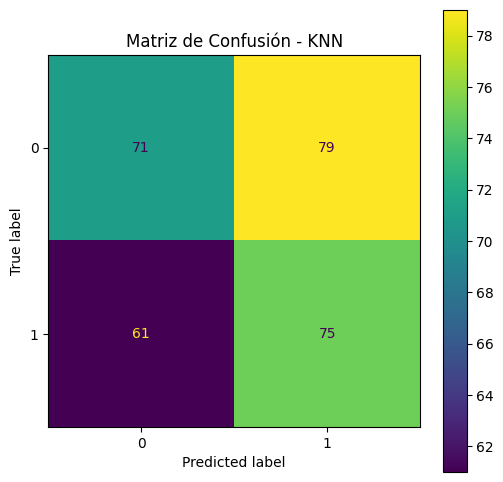

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Convert 'streams' column to numeric, replacing non-numeric values with NaN
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

# Drop rows with NaN values in 'streams' column
spotify_data = spotify_data.dropna(subset=['streams'])

# Create target variable: high or low popularity based on median of 'streams'
spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)

# Select predictor and target variables
X = spotify_data[['danceability_%', 'valence_%']]
y = spotify_data['popularity']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale predictor variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # you can adjust n_neighbors as needed
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of KNN model: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Obtener las predicciones del modelo
y_pred = knn.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax)

# Títulos y etiquetas
ax.set_title("Matriz de Confusión - KNN")
plt.show()


## Modelo Regresión Logistica

Precisión del modelo de Regresión Logística: 50.35%

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.54      0.38      0.45       150
           1       0.48      0.64      0.55       136

    accuracy                           0.50       286
   macro avg       0.51      0.51      0.50       286
weighted avg       0.51      0.50      0.50       286



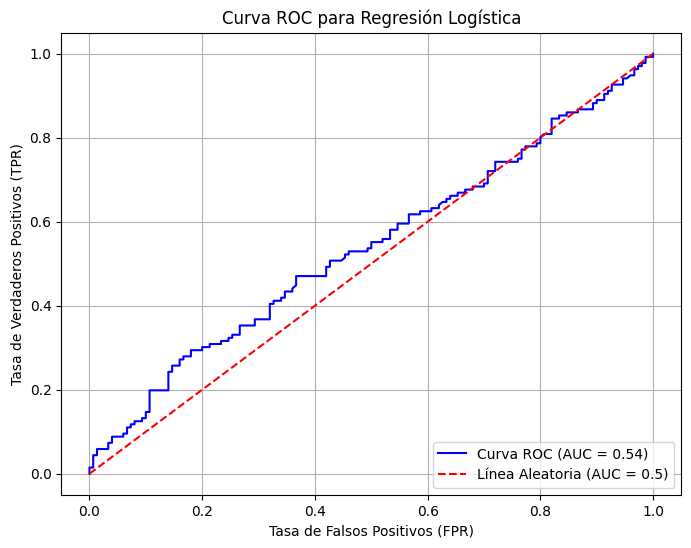

Área bajo la curva ROC (AUC): 0.54


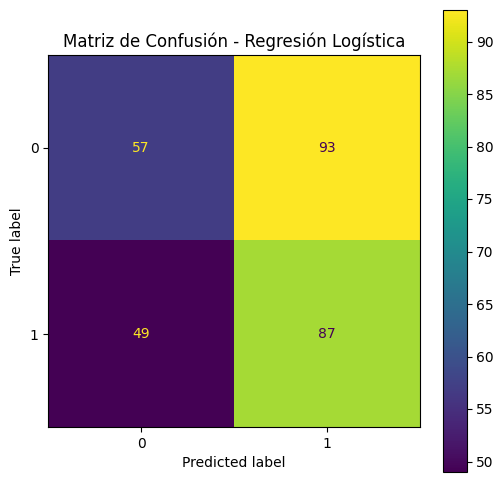

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Crear variable objetivo: alta o baja popularidad según la mediana de 'streams'
spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)

# Seleccionar variables predictoras y objetivo
X = spotify_data[['danceability_%', 'valence_%']]
y = spotify_data['popularity']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar las variables predictoras
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Realizar predicciones
y_pred = log_reg.predict(X_test)

# Evaluación del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo de Regresión Logística: {accuracy * 100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


# Obtener las probabilidades de predicción para la clase positiva
y_prob = log_reg.predict_proba(X_test)[:, 1]  # Probabilidades para la clase "1" (alta popularidad)

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el área bajo la curva ROC (AUC)
roc_auc = roc_auc_score(y_test, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Línea Aleatoria (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para Regresión Logística')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Imprimir el AUC
print(f"Área bajo la curva ROC (AUC): {roc_auc:.2f}")


# Obtener las predicciones del modelo de Regresión Logística
y_pred_log_reg = log_reg.predict(X_test)

# Calcular la matriz de confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Mostrar la matriz de confusión
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_log_reg).plot(ax=ax)

# Títulos y etiquetas
ax.set_title("Matriz de Confusión - Regresión Logística")
plt.show()




## Modelo Random forest

Precisión del modelo Random Forest: 53.15%

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.56      0.49      0.52       150
           1       0.51      0.57      0.54       136

    accuracy                           0.53       286
   macro avg       0.53      0.53      0.53       286
weighted avg       0.53      0.53      0.53       286



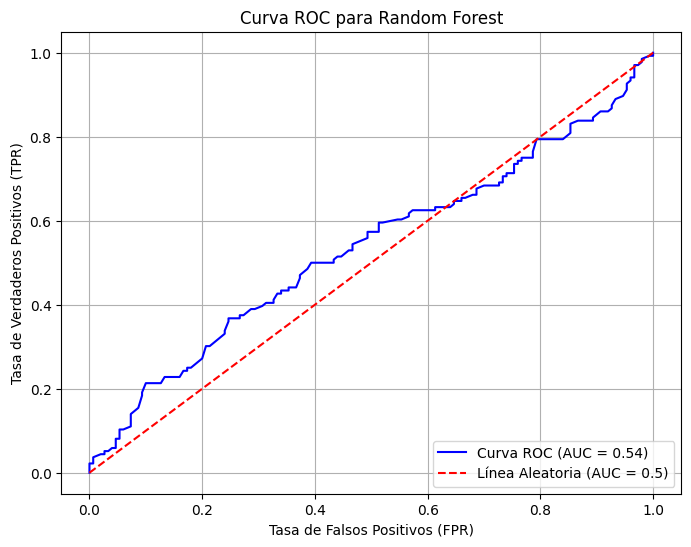

Área bajo la curva ROC (AUC): 0.54


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# Crear variable objetivo: alta o baja popularidad según la mediana de 'streams'
spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)

# Seleccionar variables predictoras y objetivo
X = spotify_data[['danceability_%', 'valence_%']]
y = spotify_data['popularity']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar las variables predictoras
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluación del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo Random Forest: {accuracy * 100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


# Obtener las probabilidades de predicción para la clase positiva
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase "1" (alta popularidad)

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el área bajo la curva ROC (AUC)
roc_auc = roc_auc_score(y_test, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Línea Aleatoria (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Imprimir el AUC
print(f"Área bajo la curva ROC (AUC): {roc_auc:.2f}")


## Modelo SVM

In [ ]:

import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')


spotify_data = spotify_data.dropna(subset=['streams'])

# Crear variable objetivo: alta o baja popularidad según la mediana de 'streams'
spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)

# Seleccionar variables predictoras y objetivo
X = spotify_data[['danceability_%', 'valence_%']]
y = spotify_data['popularity']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar las variables predictoras
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo SVM
svm = SVC(kernel='linear', random_state=42)  # Puedes probar con 'rbf' o 'poly' para otros kernels
svm.fit(X_train, y_train)

# Realizar predicciones
y_pred = svm.predict(X_test)

# Evaluación del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo SVM: {accuracy * 100:.2f}%")
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Precisión del modelo SVM: 49.30%

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.52      0.37      0.43       150
           1       0.48      0.63      0.54       136

    accuracy                           0.49       286
   macro avg       0.50      0.50      0.49       286
weighted avg       0.50      0.49      0.48       286



# Clustering


In [ ]:
# Cargar los datos de la hoja
data = spotify_data

# Mostrar las primeras filas y las columnas para explorar las variables
data.head(), data.columns


(                            track_name  artist_count  released_year  \
 0  Seven (feat. Latto) (Explicit Ver.)             2           2023   
 1                                 LALA             1           2023   
 2                              vampire             1           2023   
 3                         Cruel Summer             1           2019   
 4                       WHERE SHE GOES             1           2023   
 
    released_month  released_day  in_spotify_playlists  in_spotify_charts  \
 0               7            14                   553                147   
 1               3            23                  1474                 48   
 2               6            30                  1397                113   
 3               8            23                  7858                100   
 4               5            18                  3133                 50   
 
        streams  in_apple_playlists  in_apple_charts  ...  key   mode  \
 0  141381703.0              

## k-MEANS

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selección de las columnas relevantes
selected_columns = ['danceability_%', 'valence_%']
clustering_data = data[selected_columns].dropna()  # Eliminar filas con valores nulos

# Escalado de datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

scaled_data[:5]  # Mostrar los primeros valores escalados para verificar


array([[ 0.89005173,  1.60189118],
       [ 0.274608  ,  0.40878684],
       [-1.09304472, -0.82692837],
       [-0.81951417,  0.28095423],
       [-0.13568781, -1.2104262 ]])

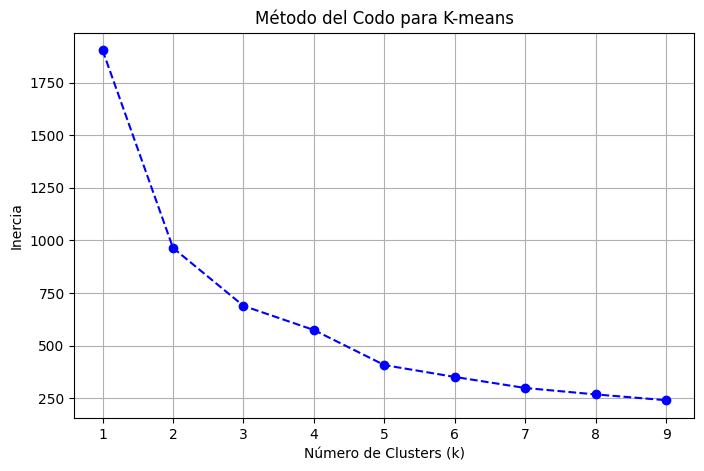

Índice de Silueta: 0.34
Davies-Bouldin Score: 0.89
Calinski-Harabasz Score: 817.02


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Selección de columnas relevantes
selected_columns = ['danceability_%', 'valence_%']
clustering_data = data[selected_columns].dropna()  # Eliminar filas con valores nulos

# Escalado de datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

# Determinación del número óptimo de clusters (método del codo)
inertia = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para K-means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_values)
plt.grid()
plt.show()

# Implementación de K-means con un número óptimo de clusters
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Evaluación de la calidad de los clusters
silhouette_avg = silhouette_score(scaled_data, clusters)
davies_bouldin = davies_bouldin_score(scaled_data, clusters)
calinski_harabasz = calinski_harabasz_score(scaled_data, clusters)

print(f"Índice de Silueta: {silhouette_avg:.2f}")
print(f"Davies-Bouldin Score: {davies_bouldin:.2f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.2f}")


## grafico

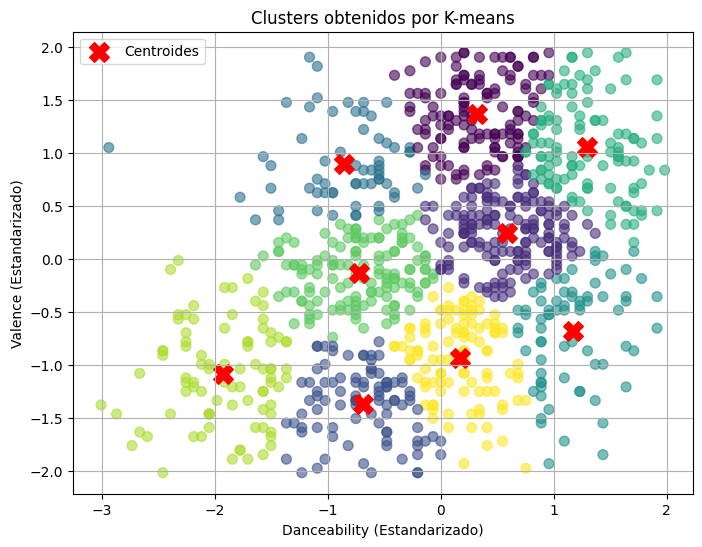

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de clusters de K-means
plt.figure(figsize=(8, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centroides')
plt.title('Clusters obtenidos por K-means')
plt.xlabel('Danceability (Estandarizado)')
plt.ylabel('Valence (Estandarizado)')
plt.legend()
plt.grid()
plt.show()


## DBSCAN


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Selección de columnas relevantes y escalado de datos
selected_columns = ['danceability_%', 'valence_%']
clustering_data = data[selected_columns].dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

# Implementación de DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Ajusta eps y min_samples según los datos
clusters = dbscan.fit_predict(scaled_data)

# Verificar si hay clusters generados
if len(np.unique(clusters)) > 1:
    # Evaluación de la calidad de los clusters
    silhouette_avg = silhouette_score(scaled_data, clusters)
    davies_bouldin = davies_bouldin_score(scaled_data, clusters)
    calinski_harabasz = calinski_harabasz_score(scaled_data, clusters)

    print(f"Índice de Silueta: {silhouette_avg:.2f}")
    print(f"Davies-Bouldin Score: {davies_bouldin:.2f}")
    print(f"Calinski-Harabasz Score: {calinski_harabasz:.2f}")
else:
    print("DBSCAN no identificó suficientes clusters para calcular métricas.")


Índice de Silueta: 0.43
Davies-Bouldin Score: 0.41
Calinski-Harabasz Score: 4.89


## Gráfico

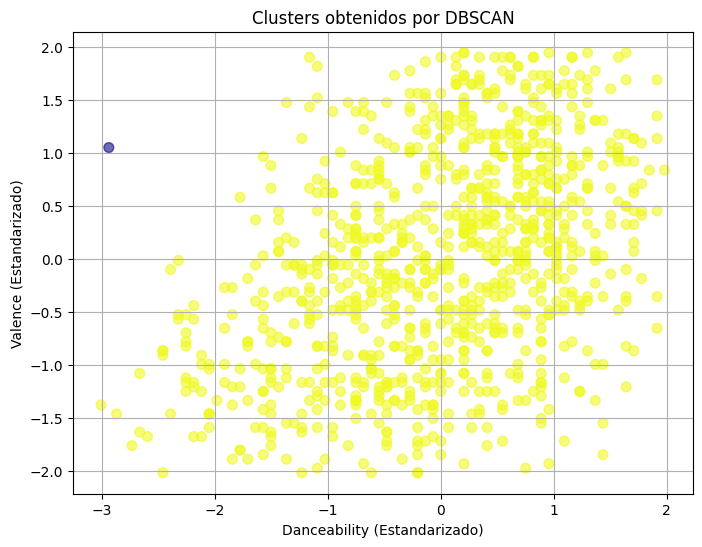

In [ ]:
# Gráfico de clusters de DBSCAN
plt.figure(figsize=(8, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=clusters, cmap='plasma', s=50, alpha=0.6)
plt.title('Clusters obtenidos por DBSCAN')
plt.xlabel('Danceability (Estandarizado)')
plt.ylabel('Valence (Estandarizado)')
plt.grid()
plt.show()


Accuracy of KNN model: 51.05%

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.47      0.50       150
           1       0.49      0.55      0.52       136

    accuracy                           0.51       286
   macro avg       0.51      0.51      0.51       286
weighted avg       0.51      0.51      0.51       286



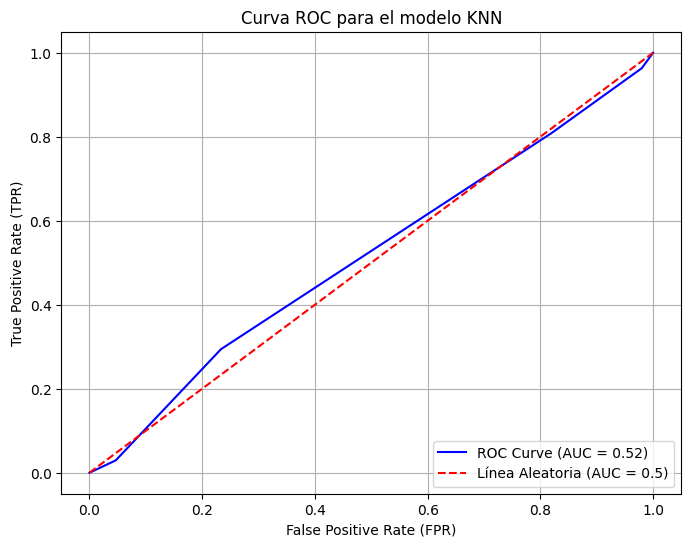

Área bajo la curva ROC (AUC): 0.52


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
# Convert 'streams' column to numeric, replacing non-numeric values with NaN
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

# Drop rows with NaN values in 'streams' column
spotify_data = spotify_data.dropna(subset=['streams'])

# Create target variable: high or low popularity based on median of 'streams'
spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)

# Select predictor and target variables
X = spotify_data[['danceability_%', 'valence_%']]
y = spotify_data['popularity']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale predictor variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # you can adjust n_neighbors as needed
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of KNN model: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Obtener las probabilidades de predicción para la clase positiva
y_prob = knn.predict_proba(X_test)[:, 1]  # Probabilidades para la clase "1" (alta popularidad)

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular el área bajo la curva ROC (AUC)
roc_auc = roc_auc_score(y_test, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Línea Aleatoria (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC para el modelo KNN')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Imprimir el AUC
print(f"Área bajo la curva ROC (AUC): {roc_auc:.2f}")


In [ ]:
import pandas as pd


# Ensure 'streams' column is numeric, coerce errors to NaN
spotify_data['streams'] = pd.to_numeric(spotify_data['streams'], errors='coerce')

# Drop rows with NaN values in 'streams' to avoid errors in median calculation
spotify_data = spotify_data.dropna(subset=['streams'])

# Create target variable: high or low popularity based on median of 'streams'
# Assign the result back to the 'popularity' column in spotify_data
spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)

# ... (rest of your code) ...

# Calculate class distribution
distribucion = spotify_data['popularity'].value_counts(normalize=True)

# Print the distribution
print(distribucion)

# Check if the variable is balanced
if abs(distribucion[0] - distribucion[1]) < 0.1:
    print("The variable is balanced.")
else:
    print("The variable is imbalanced.")


popularity
0    0.5
1    0.5
Name: proportion, dtype: float64
The variable is balanced.


<ipython-input-6-9c509f03fcd9>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_data['popularity'] = spotify_data['streams'].apply(lambda x: 1 if x > spotify_data['streams'].median() else 0)
